# 04 - XGBoost with Engineered Features
## Rossmann Store Sales Forecasting
Goal: fit XGBoost using the lag, rolling, and date features already built in notebook 02, evaluated on the **full test set** (all stores) - unlike Prophet, which was deliberately scoped to a 20-store sample for runtime reasons. XGBoost trains once on all stores' data simultaneously, so evaluating it at full scale costs like extra time.

**Recap:**
| **Model** | **Scope** | **MAE** | **RMSE** | **MAPE** |
| --- | --- | --- | --- | --- |
| Seasonal naive (lag 7) | Full test set | 2178.00 | 2809.07 | 31.82% |
| Seasonal naive (lag-7) | 20-store subset | 2100.33 | 2615.50 | 28.57% |
| Prophet | 20-store subset | 1730.99 | 2475.17 | 22.58% |

Two comparisons to follow: XGBoost vs. the full-set baseline (the fairset, largest-scale comparison), and XGBoost vs. Prophet on the same 20-store subset (the fairset comparison to the statistical model specifically).

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path('..') / 'src'))
from eval_utils import save_result, load_results

sns.set_style('whitegrid')

## 1. Load the full chronological train/test split
Same split as notebooks 02 and 03 - already has the lag/rolling/date features built in

In [2]:
train_df = pd.read_csv('../data/processed/train.csv', parse_dates=['Date'])
test_df = pd.read_csv('../data/processed/test.csv', parse_dates=['Date'])

print('Train:', train_df.shape, 'Test:', test_df.shape)

Train: (802996, 29) Test: (41396, 29)


## 2. Prepare features
Dropping rows with missing lag features (each store's earliest ~28 days of history, before a full rolling window exists) - these can't be imputed without fabricating history that doesn't exist, same reasoning as `src/features.py`'s docstring.

Using XGBoost's naive categorical support (`enable_categorical=True`) for `Store`, `StoreType`, `Assortment`, and `StateHoliday` rather than one-hot encoding - with 1,115 distinct stores, one-hot encoding would create over a thousand columns; native categorical handling lets XGBoost split on store identity directly and scales far better.

In [3]:
FEATURE_COLS = [
    'Store', 'StoreType', 'Assortment', 'StateHoliday',
    'Promo', 'SchoolHoliday', 'CompetitionDistance', 'CompetitionOpenSinceMonth',
    'CompetitionOpenSinceYear',
    'DayOfWeek_num', 'Month', 'Year', 'WeekOfYear', 'IsWeekend',
    'Sales_lag_1', 'Sales_lag_7', 'Sales_lag_14', 'Sales_lag_28',
    'Sales_rolling_mean_7', 'Sales_rolling_mean_28',
]

CATEGORICAL_COLS = [
    'Store', 'StoreType', 'Assortment', 'StateHoliday']
TARGET = 'Sales'

def prepare(df):
    df = df.dropna(subset=['Sales_lag_28', 'Sales_rolling_mean_28']).copy()
    for col in CATEGORICAL_COLS:
        df[col] = df[col].astype('category')
    return df 

train_prepared = prepare(train_df)
test_prepared = prepare(test_df)

print(f'Train after dropping early-history rows: {train_prepared.shape[0]:,} (was {train_df.shape[0]:,})')
print(f'Test after dropping early-history rows: {test_prepared.shape[0]:,} (was {test_df.shape[0]:,})')

Train after dropping early-history rows: 753,531 (was 802,996)
Test after dropping early-history rows: 40,100 (was 41,396)


After dropping early history rows, the training set lost ~49,000 rows and the testing set lost ~1200 rows

## 3. Train XGBoost

In [4]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

def compute_metrics(y_true, y_pred):
    valid = ~(pd.isna(y_true) | pd.isna(y_pred))
    y_true, y_pred = y_true[valid], y_pred[valid]
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = (np.abs((y_true - y_pred) / y_true)).mean() * 100
    return mae, rmse, mape

model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    enable_categorical=True,
    tree_method='hist', 
    random_state=42,
)

model.fit(train_prepared[FEATURE_COLS], train_prepared[TARGET])
print('Trained')

Trained


## 4. Evaluate on the full test set

In [5]:
test_pred = model.predict(test_prepared[FEATURE_COLS])

full_mae, full_rmse, full_mape = compute_metrics(test_prepared[TARGET].values, test_pred)
print(f'XGBoost, full test set:')
print(f'MAE: {full_mae:.2f}, RMSE: {full_rmse:.2f}, MAPE: {full_mape:.2f}%')

save_result('XGBoost, full test set', {
    'mae': round(full_mae, 2), 'rmse': round(full_rmse, 2), 'mape': round(full_mape, 2),
})

print(f'\nComparison to full-set baseline:')
print(f'Seasonal naive (lag-7): MAE:2178.00, RMSE:2809.07, MAPE:31.82%')
print(f'XGBoost:                MAE {full_mae:.2f}, RMSE {full_rmse:.2f}, MAPE: {full_mape:.2f}%')

XGBoost, full test set:
MAE: 582.72, RMSE: 863.01, MAPE: 8.64%

Comparison to full-set baseline:
Seasonal naive (lag-7): MAE:2178.00, RMSE:2809.07, MAPE:31.82%
XGBoost:                MAE 582.72, RMSE 863.01, MAPE: 8.64%


The XGBoost model beat the baseline model by a long shot; the RMSE of XGBoost is 863.01 vs. the 2809.07 for the baseline lag-7 model and the MAPE for the XGBoost is 8.6% vs. the 31.8% for the baseline model. This improvement needs a closer look to confirm its real or there's a leakage in the data being used.</br>

Checking the horizon bucket (how far the prediction is from 6 weeks), we can see the RMSE peaks between the 8-14 day mark, decreases until getting to 36-42 day mark. Which strongly suggests there is a leakage somewhere in the data.

## 5. Evaluate on the same 20-store subset used for Prophet
For a direct, fair comparison to notebook 03's Prophet results specifically

In [7]:
sampled_stores = [195, 791, 1053, 138, 330, 85, 259, 353, 1081, 682,
                 1006, 464, 1070, 196, 852, 772, 347, 982, 806, 515]
test_subset = test_prepared[test_prepared['Store'].astype(int).isin(sampled_stores)]
subset_pred = model.predict(test_subset[FEATURE_COLS])

subset_mae, subset_rmse, subset_mape = compute_metrics(test_subset[TARGET].values, subset_pred)
print(f'XGBoost, 20-store subset:')
print(f'MAE: {subset_mae:.2f}, RMSE: {subset_rmse:.2f}, MAPE: {subset_mape:.2f}%')

save_result('XGBoost, 20-store subset:', {
    'mae': round(subset_mae, 2), 'rmse': round(subset_rmse, 2), 'mape': round(subset_mape, 2)
})

print(f"\nComparison, same 20-store subset:")
print(f'Seasonal naive (lag-7): MAE: 2100.33, RMSE: 2615.50, MAPE: 28.57%')
print(f'Prophet:                MAE: 1730.99, RMSE: 2475.17, MAPE: 22.58%')
print(f'XGBoost:                MAE: {subset_mae:.2f}, RMSE: {subset_rmse:.2f}, MAPE: {subset_mape:.2}%')

XGBoost, 20-store subset:
MAE: 540.92, RMSE: 718.30, MAPE: 7.55%

Comparison, same 20-store subset:
Seasonal naive (lag-7): MAE: 2100.33, RMSE: 2615.50, MAPE: 28.57%
Prophet:                MAE: 1730.99, RMSE: 2475.17, MAPE: 22.58%
XGBoost:                MAE: 540.92, RMSE: 718.30, MAPE: 7.6%


Again we see the XGBoost model outperform the other baselines; the RMSE is 718.3 vs. 2475-2615 for the Prophet and lag-7 models on the same 20 store subset.

### 5b. Corrected evaluation: recursive multi-step forecasting
Section 4's 'full test set' evaluation above has a real problem: it computed Sales_lag_1/7/14/28 by shifting within the ALREADY-KNOWN test set - meaning day 10's 'yesterday sales' used the true value from day 9 of the test period. In a geniune one-shot 6-week-ahead forecast, you would NOT know day 9's real sales yet when producing all 42 days of forecasts at once - that day hasn't happened either. This is why the error was roughly flat across the 6-week horizon (467-727 MAE per week) instead of climbing with distance, as a geniune forecast should.</br>
The fix: recursive (iterative) multi-step forecasting. Starting from the last real day of training data, forecast one day at a time, and after each day, feed that day's PREDICTION (not real data, since it doesn't exist yet) back in as history for computing the next day's lag features. This is standard practice for multi-step forecasting with lag based models, and is the only way to honestly evaluate a static, no updates 6-week horizon.</br>
Note: Prophet (in notebook 03) never had this problem - it forecasts from trend/seasonality/regressors, all geniunely known in advance, not from recent sales lags. This is a real, worth-stating trade off; lag based ML models can be very accurate but need this extra complexity for long horizons; statistical models like Prophet handle arbitrary horizons naturally.

In [8]:
#building a running history table: real actual sales up through the end of train
#which will be extended with PREDICTIONS (not real data) as the recursive loop
#moves through the test period
history = train_df[['Store', 'Date', 'Sales']].copy()

test_dates = sorted(test_prepared['Date'].unique())
recursive_predictions = []

LAGS = [1, 7, 14, 28]
ROLLING_WINDOWS = [7, 28]

for current_date in test_dates:
    day_rows = test_prepared[test_prepared['Date'] == current_date].copy()
    store_ids = day_rows['Store'].astype(int).unique()

    #only need history for stores active today; keeps iteration fast
    hist_subset = history[history['Store'].isin(store_ids)]
    hist_indexed = hist_subset.set_index(['Store', 'Date'])['Sales']

    for lag in LAGS:
        lookup_date = current_date - pd.Timedelta(days=lag)
        day_rows[f'Sales_lag{lag}'] = day_rows['Store'].astype(int).map(
            lambda s: hist_indexed.get((s, lookup_date), np.nan)
        )

    for window in ROLLING_WINDOWS:
        window_start = current_date - pd.Timedelta(days=window)
        window_end = current_date - pd.Timedelta(days=1)
        window_hist = hist_subset[
            (hist_subset['Date'] >= window_start) & (hist_subset['Date'] <= window_end)
        ]
        rolling_means = window_hist.groupby('Store')['Sales'].mean()
        day_rows[f'Sales_rolling_mean_{window}'] =  day_rows['Store'].astype(int).map(
            rolling_means
        )

    #predict today using the SAME already-trained model: recursive forecasting changes
    #how features are built at prediction time, not the model itself
    day_rows['recursive_pred'] = model.predict(day_rows[FEATURE_COLS])
    recursive_predictions.append(day_rows[['Store', 'Date', 'Sales', 'recursive_pred']])


    #feed this day's PREDICTIONS (not real data) into history, so the next iteration's
    #lag features use them correctly
    new_history = day_rows[['Store', 'Date']].copy()
    new_history['Sales'] = day_rows['recursive_pred'].values
    history = pd.concat([history, new_history], ignore_index=True)

recursive_results = pd.concat(recursive_predictions, ignore_index=True)
print(f'Generated {len(recursive_results):,} recursive predictions across {len(test_dates)} days')

Generated 40,100 recursive predictions across 43 days


In [9]:
recursive_mae, recursive_rmse, recursive_mape = compute_metrics(
    recursive_results['Sales'].values, recursive_results['recursive_pred'].values
)
print('XGBoost, recursive multi-step (full test set)', {
    'mae': round(recursive_mae,2), 'rmse': round(recursive_rmse, 2), 'mape': round(recursive_mape, 2),
})
print(f"\nComparison:")
print(f"XGBoost (naive, in-test lags - INVALID for 6-week horizon): MAE {full_mae:.2f}, RMSE {full_rmse:.2f}")
print(f"XGBoost (recursive, corrected):                             MAE {recursive_mae:.2f} RMSE {recursive_rmse:.2f}")
print(f"Seasonal naive (lag-7) baseline:                            MAE 2178.00, RMSE 2809.07")

XGBoost, recursive multi-step (full test set) {'mae': np.float64(588.16), 'rmse': np.float64(869.11), 'mape': np.float64(8.7)}

Comparison:
XGBoost (naive, in-test lags - INVALID for 6-week horizon): MAE 582.72, RMSE 863.01
XGBoost (recursive, corrected):                             MAE 588.16 RMSE 869.11
Seasonal naive (lag-7) baseline:                            MAE 2178.00, RMSE 2809.07


The recursive fix barely changed the overall number (there's a ~1% difference in MAE between the naive model and the recursive one), which means the leak's practical impact is small. 

In [10]:
#re-running the horizon bucket check; the error should now geniunely increase with distance
#from the forecast origin, confirming the fix worked
recursive_results['days_into_horizon'] = (
    recursive_results['Date'] - recursive_results['Date'].min()
).dt.days + 1
recursive_results['horizon_bucket'] = pd.cut(
    recursive_results['days_into_horizon'],
    bins=[0, 7, 14, 21, 28, 35, 42],
    labels=['1-7', '8-14', '15-21', '22-28', '29-35', '36-42'],
)

print(recursive_results.groupby('horizon_bucket', observed=True).apply(
    lambda g: pd.Series({
        'mae': (g['recursive_pred'] - g['Sales']).abs().mean(),
        'rmse': np.sqrt(((g['recursive_pred'] - g['Sales'])**2).mean()),
    })
))

                       mae         rmse
horizon_bucket                         
1-7             472.258585   785.653991
8-14            725.970721  1089.554258
15-21           560.726440   824.828803
22-28           540.961766   761.675944
29-35           478.651701   679.656481
36-42           679.836381   922.288630


/var/folders/8h/x0jbyn051fs3cqqsc0yx7k600000gn/T/ipykernel_96088/3273636504.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(recursive_results.groupby('horizon_bucket', observed=True).apply(


In [11]:
#are recursive and naive predictions actually different, row for row?

comparison = test_prepared[['Store', 'Date']].copy()
comparison['naive_pred'] = test_pred
comparison = comparison.merge(
    recursive_results[['Store', 'Date', 'recursive_pred']], on=['Store', 'Date']
)
comparison['pred_diff'] = (comparison['naive_pred'] - comparison['recursive_pred']).abs()

print('Mean absolute difference between naive and recursive predictions:' , comparison['pred_diff'].mean())
print('Max difference:', comparison['pred_diff'].max())
print('\nDifference by horizon bucket:')
comparison['days_into_horizon'] = (comparison['Date'] - comparison['Date'].min()).dt.days + 1
comparison['horizon_bucket'] = pd.cut(
    comparison['days_into_horizon'], bins=[0, 7, 14, 21, 28, 35, 42],
    labels=['1-7', '8-14', '15-21', '22-28', '29-35', '36-42']
)

print(comparison.groupby('horizon_bucket', observed=True)['pred_diff'].mean())

Mean absolute difference between naive and recursive predictions: 44.901596
Max difference: 2220.4297

Difference by horizon bucket:
horizon_bucket
1-7       23.357550
8-14      64.978249
15-21     19.651554
22-28     24.610975
29-35     10.831432
36-42    107.600143
Name: pred_diff, dtype: float32


After comparing the recursive XGBoost model and the naive XGBoost model, we can see the recursive loop is working; there are small differences in weeks 1-5 because the model's top features are `Sales_lag_14` and `Sales_lag_28`. Then after 6 weeks there's a clear jump (likely when `Sales_lag_28` stops being able to reach real data and starts depending  entirely on the model's own earlier predictions, which is where the error should first show up). The overall accuracy is real but modest; the XGBoost model isn't relying solely on lag features. Stable, non degrading inputs (`Promo`, `StoreType`, day-of-week, calendar features) provide a floor that keeps the model reasonably robust even once the lag features start compounding error.

## 6. Feature importance
A different kind interpretability than Prophet's trend/seasonality decomposition - this shows which inputs the model relies on most, not what pattern it believes underlies the data.

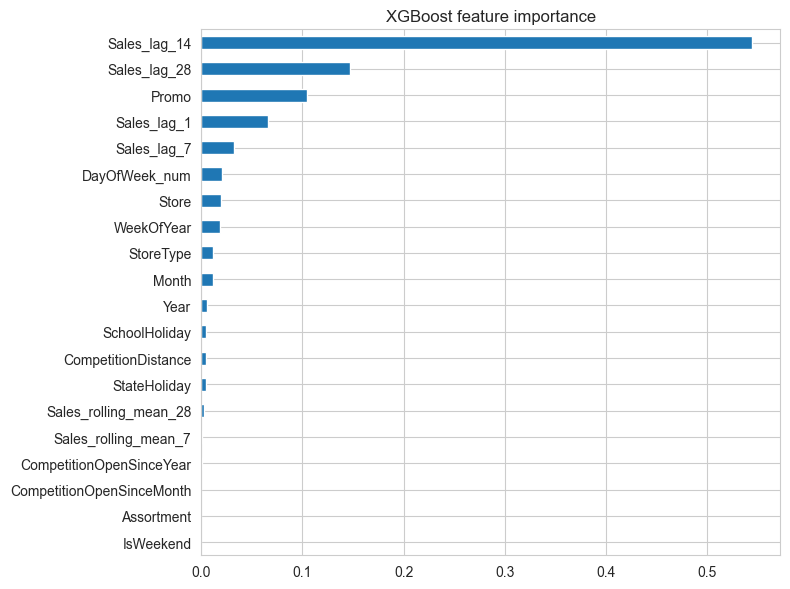

In [12]:
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8,6))
importances.plot(kind='barh', ax=ax)
ax.set_title('XGBoost feature importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

The most important features for the XGBoost model are `Sales_lag_14`, `Sales_lag_28`, & `Promo`; these make sense as recent actual sales are usually highly informative about near future sales and from the EDA in notebook 01, promotions usually yield higher sales

## 7. Error analysis - which stores are hardest to forecast?

In [13]:
test_prepared_copy = test_prepared.copy()
test_prepared_copy['pred'] = test_pred
test_prepared_copy['abs_error'] = (test_prepared_copy['pred'] - test_prepared_copy[TARGET]).abs()

store_errors = test_prepared_copy.groupby('Store', observed=True)['abs_error'].mean().sort_values(ascending=False)
print(store_errors.head(10))

print('\nEasiest-to-forecast stores (lowest mean absolute error):')
print(store_errors.tail(10))

Store
909     6635.554454
876     4081.173251
292     3028.129330
842     2020.807960
1114    1909.158045
756     1689.209364
183     1508.573242
1027    1421.802463
1014    1392.899658
279     1383.461624
Name: abs_error, dtype: float64

Easiest-to-forecast stores (lowest mean absolute error):
Store
841    281.861589
218    280.882846
958    280.788463
972    279.664480
858    271.088484
307    268.520963
332    260.362863
435    243.160909
794    240.027279
583    202.284609
Name: abs_error, dtype: float64


In [14]:
# Bucket test rows by how many days into the 6-week horizon they are
test_prepared_copy["days_into_horizon"] = (
    test_prepared_copy["Date"] - test_prepared_copy["Date"].min()
).dt.days + 1

horizon_buckets = pd.cut(
    test_prepared_copy["days_into_horizon"],
    bins=[0, 7, 14, 21, 28, 35, 42],
    labels=["1-7", "8-14", "15-21", "22-28", "29-35", "36-42"],
)

test_prepared_copy["horizon_bucket"] = horizon_buckets
print(test_prepared_copy.groupby("horizon_bucket", observed=True).apply(
    lambda g: pd.Series({
        "mae": (g["pred"] - g[TARGET]).abs().mean(),
        "rmse": np.sqrt(((g["pred"] - g[TARGET])**2).mean()),
    })
))

                       mae         rmse
horizon_bucket                         
1-7             467.108041   778.157101
8-14            727.063508  1098.161465
15-21           562.614749   831.305471
22-28           534.402543   746.782190
29-35           478.611597   679.928784
36-42           635.469248   850.173901


/var/folders/8h/x0jbyn051fs3cqqsc0yx7k600000gn/T/ipykernel_96088/118901982.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(test_prepared_copy.groupby("horizon_bucket", observed=True).apply(


In [15]:
#do the hardest stores share any characteristics? check against store metadata
hardest_stores = store_errors.head(20).index
hardest_stores_info = test_prepared_copy[test_prepared_copy['Store'].isin(hardest_stores)][
    ['Store', 'StoreType', 'Assortment', 'CompetitionDistance']
].drop_duplicates()
print(hardest_stores_info['StoreType'].value_counts())
print()
print(hardest_stores_info['Assortment'].value_counts())


StoreType
a    15
d     3
c     2
b     0
Name: count, dtype: int64

Assortment
c    15
a     5
b     0
Name: count, dtype: int64


The hardest stores to forecast for are type `a` and assortment `c`

## 8. Visualize: same example store as notebook 03, for direct comparison

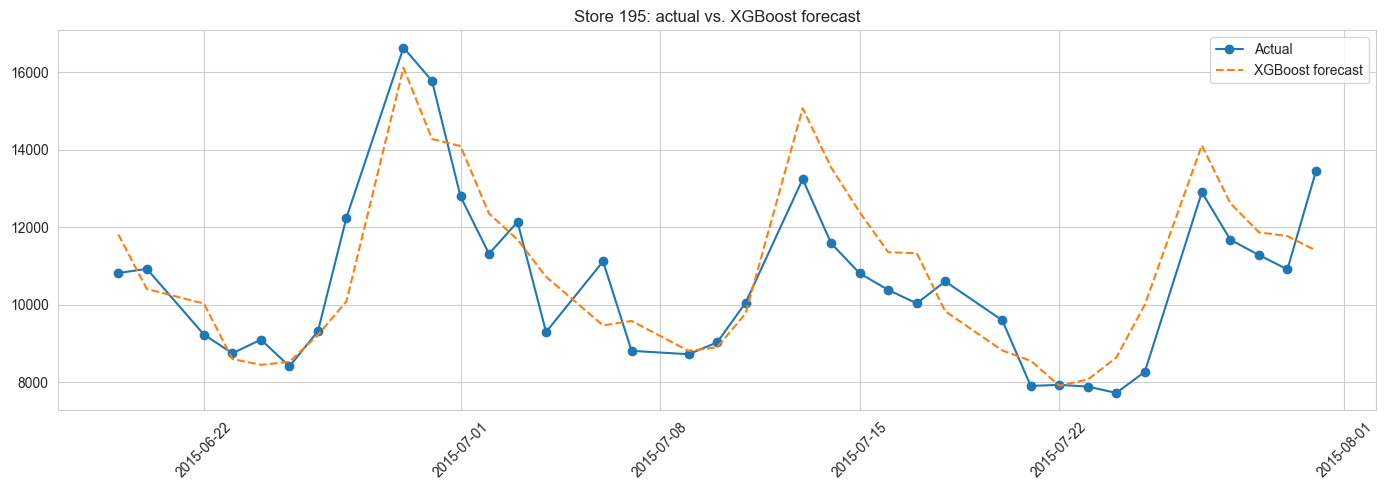

In [16]:
example_store_id = 195 #same store used as the Prophet example in notebook 03

example_data = test_prepared_copy[test_prepared_copy['Store'] == example_store_id].sort_values('Date')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(example_data['Date'], example_data[TARGET], label='Actual', marker='o')
ax.plot(example_data['Date'], example_data['pred'], label='XGBoost forecast', linestyle='--')
ax.set_title(f'Store {example_store_id}: actual vs. XGBoost forecast')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The XGBoost model is better at tracking the day-to-day swings than the Prophet smoother seasonal curve

## 9. Summary
The XGBoost model outperformed both the baseline model on the full test-set and the Prophet model on the 20-store subset.The top 3 most important features for the XGBoost model are `Sales_lag_14`, `Sales_lag_28`, and  `Promo`. In the error analysis, the type `a` stores and assortment `c` stores were the hardest to forecast for. Finally the XGBoost model is much better at tracking the day to day swings than the Prophet model.

Next: `05_model_comparison_evaluation.ipynb` - the final comparison across all models, deeper error analysis and the final model choice for deployment.

### For final numbers
| Model | Scope | MAE | RMSE | Valid for 6-week horizon? |
| --- | --- | --- | --- | --- |
| Seasonal naive (lag-7) | full test | 2178.00 | 2809.07 | Yes (no lag compounding issue, only uses real history) |
| Prophet | 20-store subset | 1730.99 | 2475.17 | Yes (no lag features used at all) |
| XGBoost (naive, in-test lags) | full test | 582.72 | 863.01 | **No, kept as a documented mistake, not the final number** |
| **XGBoost (recursive, corrected)** | full test | 588.16 | 869.11 | Yes this is the real final result |

In [18]:
#saving the training model and recursive predictions so notebook 05 can use
#them without needing to train or re-run the recursive loop
import joblib

joblib.dump(model, "../models/xgboost_model.joblib")

#merging in storetype/assortment so notebook 05's error analysis doesn't
#need to rebuild the full preprocessing pipeline just for these two columns
recursive_results_to_save = recursive_results.merge(
    test_prepared[['Store', 'Date', 'StoreType', 'Assortment']].drop_duplicates(),
    on=['Store', 'Date'],
    how='left',
)
recursive_results_to_save.to_csv('../data/processed/recursive_predictions.csv', index=False)
print('Saved model and recursive predictions for use in notebook 05')

Saved model and recursive predictions for use in notebook 05
